# Violence Detection CGN Model Builder

## Dependencies Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 13.8 MB/s eta 0:00:00


In [3]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [4]:
import tensorflow as tf

In [5]:
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, average_precision_score
from sklearn.preprocessing import label_binarize

In [6]:
import optuna

## Config

In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Device: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("Device: CPU")

Device: /physical_device:GPU:0


In [8]:
CLASSES = ['assault', 'fighting', 'shooting', 'robbery', 'normal_event']

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/violence_dataset.zip'
EXTRACT_PATH = '/content/dataset'
SAVE_DIR = '/content/drive/MyDrive/GCN_Models_Output'

RANDOM_SEED = 67
BATCH_SIZE = 64

TRIAL_EPOCH = 20
TRIAL_N = 3

TRAIN_EPOCH = 200

In [9]:
best_params = None

In [10]:
keras_model_path = os.path.join(SAVE_DIR, "GCN_LSTM_best.keras")
tflite_model_path = os.path.join(SAVE_DIR, "GCN_LSTM_best_int8.tflite")

In [11]:
if not os.path.exists(EXTRACT_PATH):
  print("Extracting Dataset...")
  with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print("Dataset has been extracted!")
else:
  print("Dataset has already been extracted previously")

Extracting Dataset...
Dataset has been extracted!


In [12]:
os.makedirs(SAVE_DIR, exist_ok=True)

## EDA

In [13]:
data_counts = {}
sample_shape = None

In [14]:
for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.npy')]
    data_counts[cls] = len(files)

    if len(files) > 0 and sample_shape is None:
      sample_path = os.path.join(folder, files[0])
      sample_data = np.load(sample_path)
      sample_shape = sample_data.shape
  else:
    data_counts[cls] = 0

In [15]:
print(f".npy Dimension Sample (C, T, V, M): {sample_shape}")

.npy Dimension Sample (C, T, V, M): (3, 100, 17, 3)


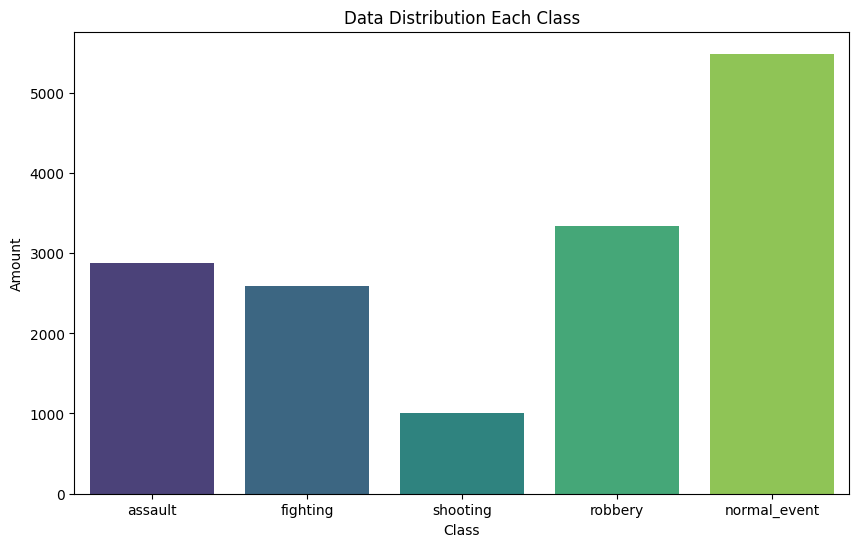

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), hue=list(data_counts.keys()), palette="viridis", legend=False)
plt.title("Data Distribution Each Class")
plt.ylabel("Amount")
plt.xlabel("Class")
plt.show()

In [17]:
print("\nFile Amount Detail:")
for k, v in data_counts.items():
  print(f"- {k}: {v} files")


File Amount Detail:
- assault: 2871 files
- fighting: 2586 files
- shooting: 1002 files
- robbery: 3332 files
- normal_event: 5489 files


## Load Dataset

In [18]:
def create_dataset_generator(file_paths, labels):
    def generator():
        for path, label in zip(file_paths, labels):
            if isinstance(path, bytes):
                path = path.decode('utf-8')
            data = np.load(path).astype(np.float32)
            yield data, label
    return generator

In [19]:
all_files = []
all_labels = []

class_map = {cls_name: i for i, cls_name in enumerate(CLASSES)}

for cls in CLASSES:
    folder = os.path.join(EXTRACT_PATH, cls)
    if os.path.exists(folder):
        files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')]
        all_files.extend(files)
        all_labels.extend([class_map[cls]] * len(files))

# Split data: 70% Train, 20% Val, 10% Test
X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.30, random_state=RANDOM_SEED, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=RANDOM_SEED, stratify=y_temp)

In [20]:
print(f"Total Dataset: {len(all_files)}")
print(f"Train: {len(X_train)} (70%) | Val: {len(X_val)} (20%) | Test: {len(X_test)} (10%)")

Total Dataset: 15280
Train: 10696 (70%) | Val: 3056 (20%) | Test: 1528 (10%)


In [21]:
def build_tf_dataset(file_paths, labels, batch_size, shuffle=True):
    dataset = tf.data.Dataset.from_generator(
        create_dataset_generator(file_paths, labels),
        output_signature=(
            tf.TensorSpec(shape=(3, 100, 17, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(file_paths), 1000))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [22]:
train_dataset = build_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dataset = build_tf_dataset(X_val, y_val, BATCH_SIZE, shuffle=False)
test_dataset = build_tf_dataset(X_test, y_test, BATCH_SIZE, shuffle=False)

## Model Architecture

In [23]:
raw_edges = [
  (0, 1), (0, 2), (1, 3), (2, 4),
  (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
  (11, 12), (5, 11), (6, 12),
  (11, 13), (13, 15), (12, 14), (14, 16)
]

In [24]:
def get_adjacency_matrix():
  A = np.zeros((17, 17))
  for i, j in raw_edges:
    A[i, j] = 1
    A[j, i] = 1
  A = A + np.eye(17)

  # Normalize
  D = np.diag(np.sum(A, axis=1) ** (-0.5))
  A_norm = np.dot(np.dot(D, A), D)
  return tf.constant(A_norm, dtype=tf.float32)

A_tensor = get_adjacency_matrix()

In [25]:
# GCN Spatial Graph Block
@keras.utils.register_keras_serializable()
class GraphConv(layers.Layer):
    def __init__(self, out_channels, num_vertices=17, adaptive=True, **kwargs):
        super().__init__(**kwargs)
        self.out_channels = out_channels
        self.num_vertices = num_vertices
        self.adaptive = adaptive

    def build(self, input_shape):
        in_channels = input_shape[-1]

        self.conv = layers.Conv2D(self.out_channels, kernel_size=1, use_bias=False)
        self.bn = layers.BatchNormalization()

        if self.adaptive:
            # Menggunakan tf.Variable untuk parameter yang bisa dipelajari
            self.PA = self.add_weight(
                shape=(self.num_vertices, self.num_vertices),
                initializer=tf.keras.initializers.RandomNormal(stddev=1e-4),
                trainable=True,
                name='PA'
            )

        if in_channels != self.out_channels:
            self.down_sample = models.Sequential([
                layers.Conv2D(self.out_channels, kernel_size=1, use_bias=False),
                layers.BatchNormalization()
            ])
        else:
            self.down_sample = lambda x: x

        super().build(input_shape)

    def call(self, x, A=None):
        if A is None:
            A = get_adjacency_matrix()

        residual = self.down_sample(x)

        x = self.conv(x)

        if self.adaptive:
            A_dynamic = A + self.PA
            x_t = tf.transpose(x, [0, 1, 3, 2]) # (N, T, C, V)
            out = tf.matmul(x_t, A_dynamic) # (N, T, C, W)
            x = tf.transpose(out, [0, 1, 3, 2]) # (N, T, W, C)
        else:
            x_t = tf.transpose(x, [0, 1, 3, 2])
            out = tf.matmul(x_t, A)
            x = tf.transpose(out, [0, 1, 3, 2])

        x = self.bn(x)
        return tf.nn.relu6(x + residual)

    def get_config(self):
        config = super().get_config()
        config.update({
            "out_channels": self.out_channels,
            "num_vertices": self.num_vertices,
            "adaptive": self.adaptive,
        })
        return config

In [26]:
# Temporal Attention Mechanism
@keras.utils.register_keras_serializable()
class TemporalAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.dense1 = layers.Dense(hidden_dim // 2, activation='tanh')
        self.dense2 = layers.Dense(1)
        super().build(input_shape)

    def call(self, lstm_out):
        attn_scores = self.dense2(self.dense1(lstm_out))
        attn_weights = tf.nn.softmax(attn_scores, axis=1)
        context_vector = tf.reduce_sum(attn_weights * lstm_out, axis=1)
        return context_vector

    def get_config(self):
        config = super().get_config()
        return config

In [27]:
@keras.utils.register_keras_serializable()
class InputReshape(layers.Layer):
    def __init__(self, M=3, T=100, V=17, C=3, **kwargs):
        super().__init__(**kwargs)
        self.M = M
        self.T = T
        self.V = V
        self.C = C

    def call(self, inputs):
        x = tf.transpose(inputs, [0, 4, 2, 3, 1])
        x = tf.reshape(x, [-1, self.T, self.V, self.C])
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M, "T": self.T, "V": self.V, "C": self.C})
        return config

@keras.utils.register_keras_serializable()
class SpatialPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, x):
        return tf.reduce_mean(x, axis=2)

@keras.utils.register_keras_serializable()
class LatePooling(layers.Layer):
    def __init__(self, M=3, hidden_dim=512, **kwargs):
        super().__init__(**kwargs)
        self.M = M
        self.hidden_dim = hidden_dim

    def call(self, x):
        x = tf.reshape(x, [-1, self.M, self.hidden_dim])
        return tf.reduce_max(x, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M, "hidden_dim": self.hidden_dim})
        return config

In [32]:
def build_gcn_model(num_classes=5, batch_size=None, hidden_gcn=64, hidden_lstm=256, lstm_layers=1, dropout_rate=0.5, unroll=False):
    inputs = keras.Input(batch_shape=(batch_size, 3, 100, 17, 3), name="input_tensor")

    M = 3; T = 100; V = 17; C = 3
    x = InputReshape(M, T, V, C, name="early_reshape")(inputs)

    # --- SPATIAL GCN PROCESSING ---
    x = GraphConv(hidden_gcn, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 2, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 2, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 4, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 4, V, adaptive=True)(x, A_tensor)

    x = SpatialPooling(name="spatial_pooling")(x)

    # --- TEMPORAL CONVOLUTION (TCN) ---
    x = layers.Conv1D(hidden_gcn * 4, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu6')(x)

    # --- LSTM PROCESSING ---
    for i in range(lstm_layers):
      x = layers.LSTM(hidden_lstm, return_sequences=True, unroll=unroll)(x)

    # --- TEMPORAL ATTENTION ---
    x = TemporalAttention()(x)
    x = LatePooling(M=M, hidden_dim=hidden_lstm, name="late_pooling")(x)

    # --- KLASIFIKASI AKHIR ---
    x = layers.Dense(hidden_lstm, activation='relu6')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="GCN_LSTM")
    return model

## Hyper Parameter Tuning

In [33]:
def objective(trial):
    print(f"\n--- Starting Trial {trial.number} ---")
    keras.backend.clear_session()

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    hidden_gcn = trial.suggest_categorical("hidden_gcn", [64, 128, 256])
    hidden_lstm = trial.suggest_categorical("hidden_lstm", [128, 256, 512])
    # lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout", 0.3, 0.6)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    model = build_gcn_model(
        num_classes=len(CLASSES),
        batch_size=BATCH_SIZE,
        hidden_gcn=hidden_gcn,
        hidden_lstm=hidden_lstm,
        dropout_rate=dropout_rate
    )

    optimizer = optimizers.Adam(learning_rate=lr, weight_decay=weight_decay)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=7, min_lr=(lr / 100))
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=TRIAL_EPOCH,
        callbacks=[early_stop, reduce_lr, optuna.integration.TFKerasPruningCallback(trial, "val_loss")],
        # callbacks=[early_stop, reduce_lr],
        verbose=2
    )

    return min(history.history['val_loss'])

In [34]:
study_gcn_lstm = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())

[I 2026-06-02 05:00:43,075] A new study created in memory with name: no-name-11bcd816-f79e-4100-be7a-31722b09a88a


In [35]:
if best_params is None:
  study_gcn_lstm.optimize(objective, n_trials=TRIAL_N)
else:
  print('Skipping hyperparameter tuning')


--- Starting Trial 0 ---
Epoch 1/20


/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.tfkeras` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.tfkeras` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


168/168 - 100s - 596ms/step - accuracy: 0.4690 - loss: 1.2914 - val_accuracy: 0.4110 - val_loss: 1.3753 - learning_rate: 4.0549e-04
Epoch 2/20
168/168 - 74s - 442ms/step - accuracy: 0.5473 - loss: 1.1433 - val_accuracy: 0.5272 - val_loss: 1.1817 - learning_rate: 4.0549e-04
Epoch 3/20
168/168 - 74s - 442ms/step - accuracy: 0.5714 - loss: 1.0770 - val_accuracy: 0.4519 - val_loss: 1.2892 - learning_rate: 4.0549e-04
Epoch 4/20
168/168 - 74s - 442ms/step - accuracy: 0.6051 - loss: 1.0090 - val_accuracy: 0.5546 - val_loss: 1.1394 - learning_rate: 4.0549e-04
Epoch 5/20
168/168 - 74s - 442ms/step - accuracy: 0.6361 - loss: 0.9452 - val_accuracy: 0.5658 - val_loss: 1.1032 - learning_rate: 4.0549e-04
Epoch 6/20
168/168 - 74s - 442ms/step - accuracy: 0.6315 - loss: 0.9541 - val_accuracy: 0.5864 - val_loss: 1.0488 - learning_rate: 4.0549e-04
Epoch 7/20
168/168 - 74s - 442ms/step - accuracy: 0.6664 - loss: 0.8698 - val_accuracy: 0.6515 - val_loss: 0.9232 - learning_rate: 4.0549e-04
Epoch 8/20
168/1

[I 2026-06-02 05:25:55,494] Trial 0 finished with value: 0.6684536337852478 and parameters: {'lr': 0.0004054897316854834, 'hidden_gcn': 256, 'hidden_lstm': 128, 'dropout': 0.30122158429823936, 'weight_decay': 0.00024913104098935084}. Best is trial 0 with value: 0.6684536337852478.



--- Starting Trial 1 ---
Epoch 1/20
168/168 - 48s - 283ms/step - accuracy: 0.4439 - loss: 1.3388 - val_accuracy: 0.4398 - val_loss: 1.4021 - learning_rate: 0.0019
Epoch 2/20
168/168 - 37s - 221ms/step - accuracy: 0.5086 - loss: 1.2172 - val_accuracy: 0.4457 - val_loss: 1.5734 - learning_rate: 0.0019
Epoch 3/20
168/168 - 37s - 222ms/step - accuracy: 0.5422 - loss: 1.1468 - val_accuracy: 0.4712 - val_loss: 1.2734 - learning_rate: 0.0019
Epoch 4/20
168/168 - 37s - 222ms/step - accuracy: 0.5657 - loss: 1.0900 - val_accuracy: 0.5075 - val_loss: 1.2130 - learning_rate: 0.0019
Epoch 5/20
168/168 - 37s - 222ms/step - accuracy: 0.5921 - loss: 1.0475 - val_accuracy: 0.5874 - val_loss: 1.0339 - learning_rate: 0.0019
Epoch 6/20
168/168 - 37s - 222ms/step - accuracy: 0.6045 - loss: 1.0074 - val_accuracy: 0.5690 - val_loss: 1.1067 - learning_rate: 0.0019
Epoch 7/20
168/168 - 37s - 222ms/step - accuracy: 0.6286 - loss: 0.9610 - val_accuracy: 0.5785 - val_loss: 1.0712 - learning_rate: 0.0019
Epoch 8/

[I 2026-06-02 05:38:31,396] Trial 1 finished with value: 0.6826181411743164 and parameters: {'lr': 0.0018927679395474664, 'hidden_gcn': 128, 'hidden_lstm': 256, 'dropout': 0.4369207330704566, 'weight_decay': 1.0731509238220163e-05}. Best is trial 0 with value: 0.6684536337852478.



--- Starting Trial 2 ---
Epoch 1/20
168/168 - 84s - 498ms/step - accuracy: 0.4511 - loss: 1.3188 - val_accuracy: 0.4110 - val_loss: 1.6186 - learning_rate: 8.2132e-04
Epoch 2/20
168/168 - 75s - 447ms/step - accuracy: 0.5065 - loss: 1.2062 - val_accuracy: 0.4244 - val_loss: 1.6617 - learning_rate: 8.2132e-04
Epoch 3/20
168/168 - 75s - 447ms/step - accuracy: 0.5495 - loss: 1.1187 - val_accuracy: 0.4689 - val_loss: 1.5827 - learning_rate: 8.2132e-04
Epoch 4/20
168/168 - 75s - 447ms/step - accuracy: 0.5706 - loss: 1.0751 - val_accuracy: 0.4758 - val_loss: 1.4510 - learning_rate: 8.2132e-04
Epoch 5/20
168/168 - 75s - 447ms/step - accuracy: 0.5995 - loss: 1.0256 - val_accuracy: 0.5658 - val_loss: 1.0863 - learning_rate: 8.2132e-04
Epoch 6/20
168/168 - 75s - 447ms/step - accuracy: 0.6281 - loss: 0.9484 - val_accuracy: 0.5674 - val_loss: 1.1680 - learning_rate: 8.2132e-04
Epoch 7/20
168/168 - 75s - 447ms/step - accuracy: 0.6400 - loss: 0.9203 - val_accuracy: 0.5812 - val_loss: 1.0681 - learni

[I 2026-06-02 06:03:43,832] Trial 2 finished with value: 0.6441420912742615 and parameters: {'lr': 0.0008213190406291645, 'hidden_gcn': 256, 'hidden_lstm': 512, 'dropout': 0.48873596532952557, 'weight_decay': 8.091860155829206e-05}. Best is trial 2 with value: 0.6441420912742615.


In [36]:
if best_params is None:
  print("=== Best Params ===")
  print(study_gcn_lstm.best_params)

=== Best Params ===
{'lr': 0.0008213190406291645, 'hidden_gcn': 256, 'hidden_lstm': 512, 'dropout': 0.48873596532952557, 'weight_decay': 8.091860155829206e-05}


## Model Training

In [37]:
if best_params is None:
  best_params = study_gcn_lstm.best_params

In [38]:
keras.backend.clear_session()

In [39]:
model = build_gcn_model(
    batch_size=BATCH_SIZE,
    num_classes=len(CLASSES),
    hidden_gcn=best_params['hidden_gcn'],
    hidden_lstm=best_params['hidden_lstm'],
    dropout_rate=best_params['dropout']
)

optimizer = optimizers.Adam(learning_rate=best_params['lr'], weight_decay=best_params['weight_decay'])

In [40]:
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [41]:
model.summary()

Model: "GCN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (64, 3, 100, 17, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (InputReshape)    │ (192, 100, 17, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv (GraphConv)          │ (192, 100, 17, 256)    │         3,873 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_1 (GraphConv)        │ (192, 100, 17, 512)    │       266,529 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_2 (GraphConv)        │ (192, 100, 17, 512)    │       264,481 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_3 (GraphConv)        │ (192, 100, 17, 1024)   │     1,057,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_4 (GraphConv)        │ (192, 100, 17, 1024)   │     1,052,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_pooling                 │ (192, 100, 1024)       │             0 │
│ (SpatialPooling)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (192, 100, 1024)       │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (192, 100, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (192, 100, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (192, 100, 512)        │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (192, 512)             │       131,585 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling (LatePooling)      │ (64, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, 512)              │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 5)                │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,340,331 (35.63 MB)

 Trainable params: 9,328,043 (35.58 MB)

 Non-trainable params: 12,288 (48.00 KB)

In [42]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=20, min_lr=(best_params['lr'] / 100))
model_checkpoint = callbacks.ModelCheckpoint(keras_model_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=45, restore_best_weights=True)

In [43]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=TRAIN_EPOCH,
    callbacks=[reduce_lr, model_checkpoint, early_stopping]
)

Epoch 1/200
    168/Unknown 79s 419ms/step - accuracy: 0.4100 - loss: 1.4100
Epoch 1: val_loss improved from None to 1.47379, saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 451ms/step - accuracy: 0.4452 - loss: 1.3367 - val_accuracy: 0.3815 - val_loss: 1.4738 - learning_rate: 8.2132e-04
Epoch 2/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5024 - loss: 1.2209
Epoch 2: val_loss improved from 1.47379 to 1.21495, saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 76s 447ms/step - accuracy: 0.5080 - loss: 1.2061 - val_accuracy: 0.5049 - val_loss: 1.2149 - learning_rate: 8.2132e-04
Epoch 3/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.5444 - loss: 1.1273
Ep

## Train Result

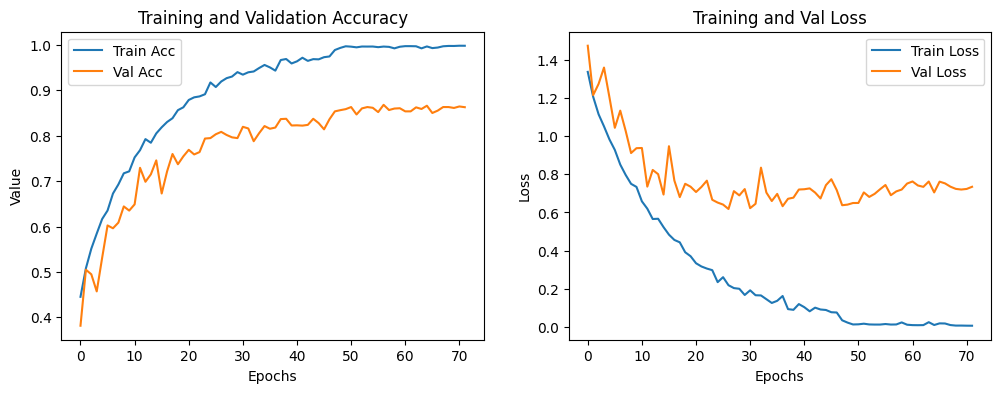

In [44]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model Test

In [45]:
test_model = keras.models.load_model(keras_model_path, custom_objects={
    'GraphConv': GraphConv,
    'TemporalAttention': TemporalAttention,
    'InputReshape': InputReshape,
    'SpatialPooling': SpatialPooling,
    'LatePooling': LatePooling
})

test_model.summary()

Model: "GCN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (64, 3, 100, 17, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (InputReshape)    │ (192, 100, 17, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv (GraphConv)          │ (192, 100, 17, 256)    │         3,873 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_1 (GraphConv)        │ (192, 100, 17, 512)    │       266,529 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_2 (GraphConv)        │ (192, 100, 17, 512)    │       264,481 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_3 (GraphConv)        │ (192, 100, 17, 1024)   │     1,057,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_4 (GraphConv)        │ (192, 100, 17, 1024)   │     1,052,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_pooling                 │ (192, 100, 1024)       │             0 │
│ (SpatialPooling)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (192, 100, 1024)       │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (192, 100, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (192, 100, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (192, 100, 512)        │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (192, 512)             │       131,585 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling (LatePooling)      │ (64, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, 512)              │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 5)                │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,996,419 (106.80 MB)

 Trainable params: 9,328,043 (35.58 MB)

 Non-trainable params: 12,288 (48.00 KB)

 Optimizer params: 18,656,088 (71.17 MB)

In [46]:
test_loss, test_acc = test_model.evaluate(test_dataset)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8187 - loss: 0.6350


In [47]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.6350
Test Acc: 0.8187


In [48]:
y_pred_prob = test_model.predict(test_dataset)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step


In [49]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


=== Classification Report ===
              precision    recall  f1-score   support

     assault     0.7883    0.7526    0.7701       287
    fighting     0.7732    0.8031    0.7879       259
    shooting     0.7662    0.5900    0.6667       100
     robbery     0.7873    0.7447    0.7654       333
normal_event     0.8769    0.9472    0.9107       549

    accuracy                         0.8187      1528
   macro avg     0.7984    0.7675    0.7801      1528
weighted avg     0.8159    0.8187    0.8158      1528



In [50]:
print("=== Average Precision (AP) per class ===")
ap_scores = []
for i, cls in enumerate(CLASSES):
    ap = average_precision_score(y_true_bin[:, i], y_pred_prob[:, i])
    ap_scores.append(ap)
    print(f"{cls}: {ap:.4f}")

mAP = np.mean(ap_scores)
print(f"\nMean Average Precision (mAP50 equivalent): {mAP:.4f}")

=== Average Precision (AP) per class ===
assault: 0.8297
fighting: 0.8630
shooting: 0.7225
robbery: 0.8575
normal_event: 0.9770

Mean Average Precision (mAP50 equivalent): 0.8499


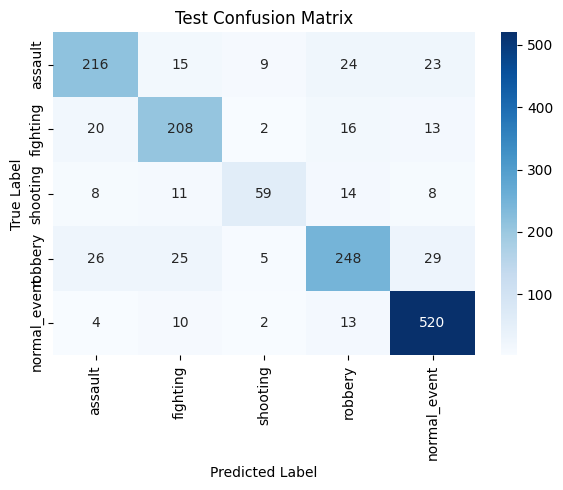

In [51]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## TFLite Conversion (Full Integer Quantization)

In [52]:
def representative_data_gen():
    for input_value, _ in train_dataset.unbatch().batch(1).take(100):
        yield [tf.cast(input_value, tf.float32).numpy()]

In [53]:
with tf.device('/CPU:0'):
    saved_model = keras.models.load_model(keras_model_path, custom_objects={
        'GraphConv': GraphConv,
        'TemporalAttention': TemporalAttention,
        'InputReshape': InputReshape,
        'SpatialPooling': SpatialPooling,
        'LatePooling': LatePooling
    })

    model_for_tflite = build_gcn_model(
        num_classes=len(CLASSES),
        batch_size=1,
        hidden_gcn=best_params['hidden_gcn'],
        hidden_lstm=best_params['hidden_lstm'],
        dropout_rate=best_params['dropout'],
        unroll=True
    )
    model_for_tflite.set_weights(saved_model.get_weights())

In [54]:
model_for_tflite.summary()

Model: "GCN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (1, 3, 100, 17, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (InputReshape)    │ (3, 100, 17, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_5 (GraphConv)        │ (3, 100, 17, 256)      │         3,873 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_6 (GraphConv)        │ (3, 100, 17, 512)      │       266,529 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_7 (GraphConv)        │ (3, 100, 17, 512)      │       264,481 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_8 (GraphConv)        │ (3, 100, 17, 1024)     │     1,057,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_9 (GraphConv)        │ (3, 100, 17, 1024)     │     1,052,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_pooling                 │ (3, 100, 1024)         │             0 │
│ (SpatialPooling)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (3, 100, 1024)         │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (3, 100, 1024)         │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (3, 100, 1024)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (3, 100, 512)          │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_1            │ (3, 512)               │       131,585 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling (LatePooling)      │ (1, 512)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (1, 512)               │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 512)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 5)                 │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,340,331 (35.63 MB)

 Trainable params: 9,328,043 (35.58 MB)

 Non-trainable params: 12,288 (48.00 KB)

In [55]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_tflite)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

In [56]:
print("Konversi model ke TFLite...")
try:
    tflite_quant_model = converter.convert()
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_quant_model)
    print(f"TFLite model successfully saved to {tflite_model_path}")

    model_size_kb = os.path.getsize(tflite_model_path) / 1024
    print(f"Quantized Model Size: {model_size_kb:.2f} KB")
except Exception as e:
    print(f"Failed to convert model to TFLite: {e}")

Konversi model ke TFLite...
Saved artifact at '/tmp/tmp2nqoi64i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 3, 100, 17, 3), dtype=tf.float32, name='input_tensor')
Output Type:
  TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
Captures:
  134858654081360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654079824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654081168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654073680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654082320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654081936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858657930832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134863993303120: TensorSpec(shape=(17, 17), dtype=tf.float32, name=None)
  134858654081552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134858654082128: TensorSpec(shape=(), dtype=tf.resource

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model successfully saved to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8.tflite
Quantized Model Size: 10018.07 KB


## Compile with Edge TPU Compiler

reference: [coral.ai Web-based Edge TPU Compiler](https://colab.research.google.com/github/google-coral/tutorials/blob/master/compile_for_edgetpu.ipynb)

In [57]:
! curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -

! echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list

! sudo apt-get update

! sudo apt-get install edgetpu-compiler

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1022  100  1022    0     0  12773      0 --:--:-- --:--:-- --:--:-- 12936
OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://packages.cloud.google.com/apt coral-edgetpu-stable InRelease [1,423 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,703 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-update

In [58]:
!edgetpu_compiler {tflite_model_path}

Edge TPU Compiler version 16.0.384591198
Started a compilation timeout timer of 180 seconds.

Model compiled successfully in 28811 ms.

Input model: /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8.tflite
Input size: 9.78MiB
Output model: GCN_LSTM_best_int8_edgetpu.tflite
Output size: 17.62MiB
On-chip memory used for caching model parameters: 5.05MiB
On-chip memory remaining for caching model parameters: 2.85MiB
Off-chip memory used for streaming uncached model parameters: 3.09MiB
Number of Edge TPU subgraphs: 1
Total number of operations: 1455
Operation log: GCN_LSTM_best_int8_edgetpu.log

Model successfully compiled but not all operations are supported by the Edge TPU. A percentage of the model will instead run on the CPU, which is slower. If possible, consider updating your model to use only operations supported by the Edge TPU. For details, visit g.co/coral/model-reqs.
Number of operations that will run on Edge TPU: 1395
Number of operations that will run on CPU: 60
See 

In [59]:
base_path, ext = os.path.splitext(tflite_model_path)
edgetpu_dest_path = f"{base_path}_edgetpu{ext}"
edgetpu_log_dest_path = f"{base_path}_edgetpu.log"

edgetpu_source_filename = f"{os.path.basename(base_path)}_edgetpu{ext}"
edgetpu_log_filename = f"{os.path.basename(base_path)}_edgetpu.log"

edgetpu_source_path = os.path.join('/content', edgetpu_source_filename)
edgetpu_log_path = os.path.join('/content', edgetpu_log_filename)

if os.path.exists(edgetpu_source_path):
    shutil.move(edgetpu_source_path, edgetpu_dest_path)
    print(f"Edge TPU Model has been moved to: {edgetpu_dest_path}")
else:
    print(f"Moving Failed. File source not found: {edgetpu_source_path}")

if os.path.exists(edgetpu_log_path):
    shutil.move(edgetpu_log_path, edgetpu_log_dest_path)
    print(f"Edge TPU Model has been moved to: {edgetpu_log_dest_path}")
else:
    print(f"Moving Failed. File source not found: {edgetpu_log_path}")

Edge TPU Model has been moved to: /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8_edgetpu.tflite
Edge TPU Model has been moved to: /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8_edgetpu.log


## Additionaly convert YOLO Model to Edge TPU TFLite as well

In [60]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.0 MB/s eta 0:00:00


In [61]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [62]:
!yolo export model=yolov8n-pose.pt format=edgetpu imgsz=256 int8=True

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ EDGETPU export does not support end2end models, disabling end2end branch.
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8-pose.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-pose summary (fused): 81 layers, 3,289,964 parameters, 0 gradients, 9.2 GFLOPs

PyTorch: starting from 'yolov8n-pose.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 56, 1344) (6.5 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8-pose.yaml'

WARNING ⚠️ Dataset 'coco8-pose.yaml' images not found, missing path '/content/datasets/coco8-pose/images/val'
Unzipping /content/datasets/coco8-pose.zip to /content/datasets/coco8-pose...: 100% ━━━━━━━━━━━━ 27/27 4.2Kfiles/s 0.0s
Dataset download success ✅ (0.6s), saved to /conten

In [63]:
edgetpu_yolo_model_path = "/content/yolov8n-pose_saved_model/yolov8n-pose_full_integer_quant_edgetpu.tflite"

In [64]:
yolo_base_path, yolo_ext = os.path.splitext(edgetpu_yolo_model_path)

yolo_edgetpu_source_filename = f"{os.path.basename(yolo_base_path)}{yolo_ext}"
yolo_edgetpu_dest_path = os.path.join(SAVE_DIR, yolo_edgetpu_source_filename)

# Memindahkan file jika ada
if os.path.exists(edgetpu_yolo_model_path):
    shutil.move(edgetpu_yolo_model_path , yolo_edgetpu_dest_path)
    print(f"Model Edge TPU berhasil dipindahkan ke: {yolo_edgetpu_dest_path}")
else:
    print(f"Gagal memindahkan. File sumber tidak ditemukan: {edgetpu_yolo_model_path}")

Model Edge TPU berhasil dipindahkan ke: /content/drive/MyDrive/GCN_Models_Output/yolov8n-pose_full_integer_quant_edgetpu.tflite
